# Simulation_OLP

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode, LL_RT

# Load data

In [16]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_MV_2026-03-09-17h33.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable)    

MV


# Parameters optimal FOPDT & SOPDT models

In [17]:
Kp_FOPDTOPT =  0.3597106684897373
T_FOPDTOPT =  176.6076909631935
theta_FOPDTOPT = 36.54240018262756

Kp_SOPDTOPT = 0.35898127140235636
T1_SOPDTOPT = 170.82166650170737
T2_SOPDTOPT = 26.554799326329196
theta_SOPDTOPT = 13.31337666961241 

Tu = 38 
Tg = 214
t1 = 100
t2 = 123
a =0.1
Kp = 0.35
print(Tu/Tg)

T1_Grin = Tg * (((3*a*np.e)-1)/(1+(a*np.e)))
T2_Grin = Tg * ((1-(a*np.e))/(1+(a*np.e)))
theta_Grin = Tu - ((T1_Grin*T2_Grin)/(T1_Grin + (3 * T2_Grin)))
T_str = Tg / 2.72
theta_str = Tu - (0.10*Tg)
T_com = 5.5*(t2-t1)
theta_com = (2.8*t1) - (1.8*t2)
print(T1_Grin, T2_Grin, theta_str, theta_com )
Ts = 1


0.17757009345794392
-31.046887579242654 122.52344378962133 16.599999999999998 58.599999999999994


# Compare step responses (experiment compared with optimal FOPDT & SOPDT)

(0.0, 1229.0)

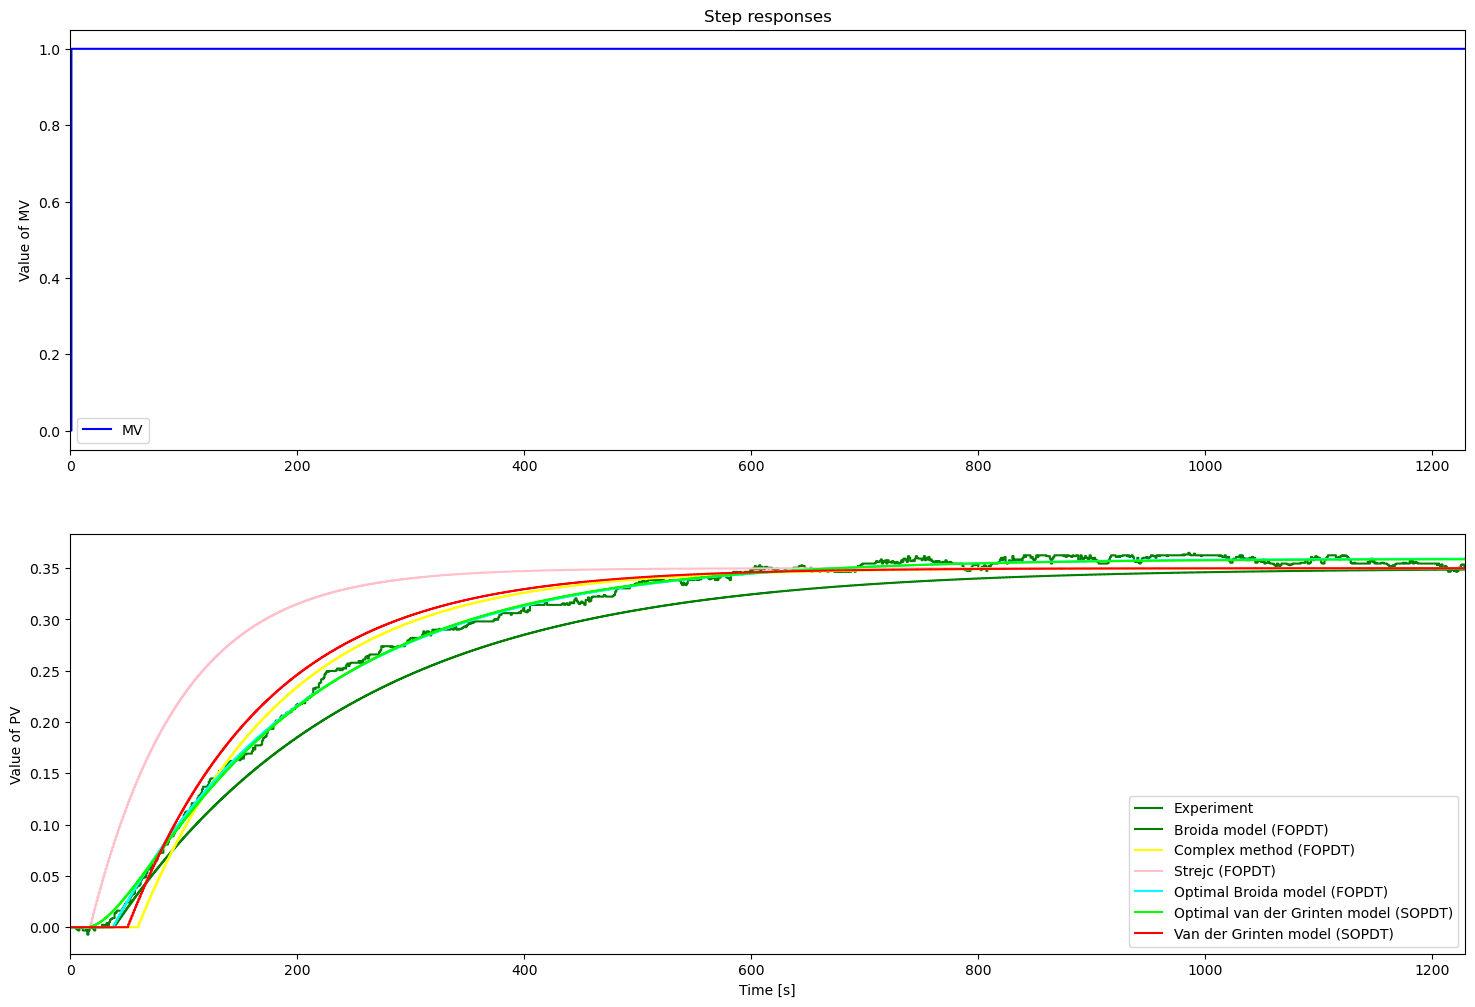

In [18]:
PV_SOPDTOPT_cost = SOPDT(MVm,Kp_SOPDTOPT,T1_SOPDTOPT,T2_SOPDTOPT,theta_SOPDTOPT,Ts)
PV_FOPDTOPT_cost = FOPDT(MVm,Kp_FOPDTOPT,T_FOPDTOPT,theta_FOPDTOPT,Ts)
PV_FOPDTOPT_Bro = FOPDT(MVm,Kp,Tg,Tu,Ts)
PV_FOPDTOPT_com = FOPDT(MVm,Kp,T_com,theta_com,Ts)
PV_SOPDTOPT_Grin = SOPDT(MVm,Kp,0,T2_Grin,theta_Grin,Ts)
PV_FOPDTOPT_str = FOPDT(MVm,Kp,T_str,theta_str,Ts)


plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   

plt.subplot(2,1,2)
plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTOPT_Bro,'g',label='Broida model (FOPDT)',where='post')
plt.step(tm,PV_FOPDTOPT_com,'yellow',label='Complex method (FOPDT)',where='post')
plt.step(tm,PV_FOPDTOPT_str,'pink',label='Strejc (FOPDT)',where='post')

plt.step(tm,PV_FOPDTOPT_cost,'cyan',label='Optimal Broida model (FOPDT)',where='post')
plt.step(tm,PV_SOPDTOPT_cost,'lime',label='Optimal van der Grinten model (SOPDT)',where='post')
plt.step(tm,PV_SOPDTOPT_Grin,'r',label='Van der Grinten model (SOPDT)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])

# Compare Bode diagrams (optimal FOPDT & SOPDT)

Text(0, 0.5, 'Phase [°]')

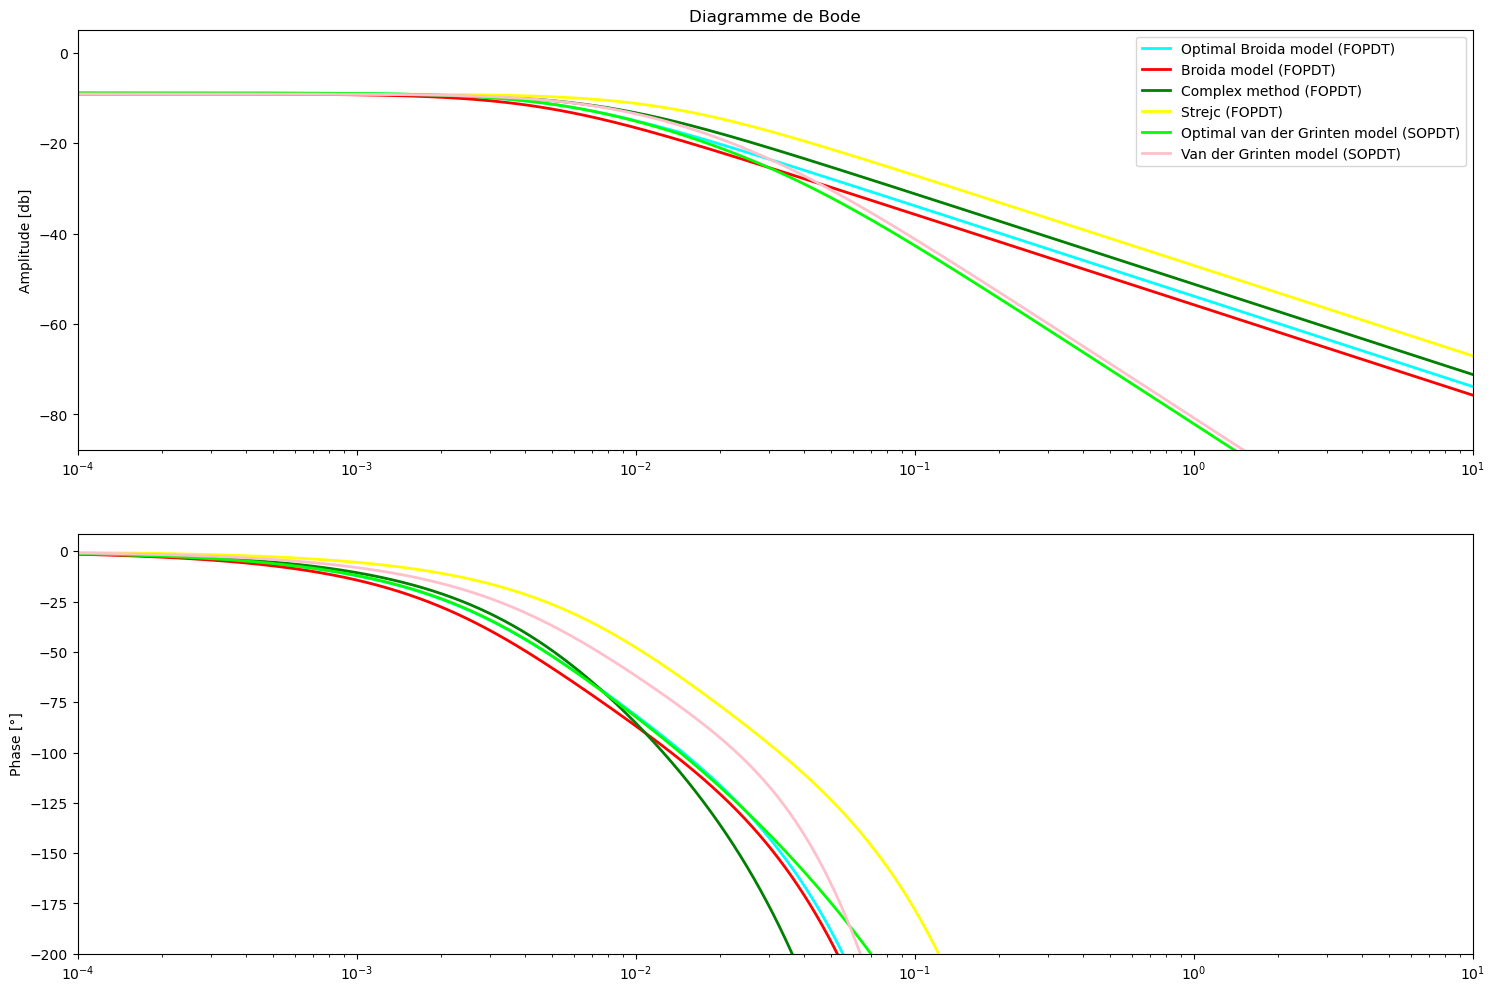

In [19]:
# Frequency response Optimal/cost FOPDT
P_FOPDTOPT = Process({})
P_FOPDTOPT.parameters['Kp'] = Kp_FOPDTOPT
P_FOPDTOPT.parameters['Tlag1'] = T_FOPDTOPT
P_FOPDTOPT.parameters['theta'] = theta_FOPDTOPT

P_FOPDTOPT_Bro = Process({})
P_FOPDTOPT_Bro.parameters['Kp'] = Kp
P_FOPDTOPT_Bro.parameters['Tlag1'] = Tg
P_FOPDTOPT_Bro.parameters['theta'] = Tu

P_FOPDTOPT_com = Process({})
P_FOPDTOPT_com.parameters['Kp'] = Kp
P_FOPDTOPT_com.parameters['Tlag1'] = T_com
P_FOPDTOPT_com.parameters['theta'] = theta_com

P_FOPDTOPT_str = Process({})
P_FOPDTOPT_str.parameters['Kp'] = Kp
P_FOPDTOPT_str.parameters['Tlag1'] = T_str
P_FOPDTOPT_str.parameters['theta'] = theta_str

# Frequency response Optimal/cost SOPDT
P_SOPDTOPT = Process({})
P_SOPDTOPT.parameters['Kp'] = Kp_SOPDTOPT
P_SOPDTOPT.parameters['Tlag1'] = T1_SOPDTOPT
P_SOPDTOPT.parameters['Tlag2'] = T2_SOPDTOPT
P_SOPDTOPT.parameters['theta'] = theta_SOPDTOPT

P_SOPDTOPT_GRIN = Process({})
P_SOPDTOPT_GRIN.parameters['Kp'] = Kp
P_SOPDTOPT_GRIN.parameters['Tlag1'] = T1_Grin
P_SOPDTOPT_GRIN.parameters['Tlag2'] = T2_Grin
P_SOPDTOPT_GRIN.parameters['theta'] = theta_Grin

omega = np.logspace(-4, 1, 10000)
Ps_FOPDTOPT = Bode(P_FOPDTOPT,omega,False) # Optimal Broida
Ps_FOPDTOPT_Bro = Bode(P_FOPDTOPT_Bro,omega,False)
Ps_FOPDTOPT_com = Bode(P_FOPDTOPT_com,omega,False)
Ps_FOPDTOPT_str = Bode(P_FOPDTOPT_str,omega,False)
Ps_SOPDTOPT = Bode(P_SOPDTOPT,omega,False) # Optimal van der Grinten
Ps_SOPDTOPT_GRIN = Bode(P_SOPDTOPT_GRIN,omega,False)


plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
gain_min = np.min(20*np.log10(np.abs(Ps_FOPDTOPT)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_FOPDTOPT)*5))
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT)),'cyan',linewidth=2,label='Optimal Broida model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT_Bro)),'r',linewidth=2,label='Broida model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT_com)),'g',linewidth=2,label='Complex method (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT_str)),'yellow',linewidth=2,label='Strejc (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT)),'lime',linewidth=2,label='Optimal van der Grinten model (SOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT_GRIN)),'pink',linewidth=2,label='Van der Grinten model (SOPDT)')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [db]')
plt.title('Diagramme de Bode')
plt.legend(loc='best')

plt.subplot(2,1,2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT)),'cyan',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT_Bro)),'r',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT_com)),'g',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT_str)),'yellow',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT)),'lime',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT_GRIN)),'pink',linewidth=2)
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')

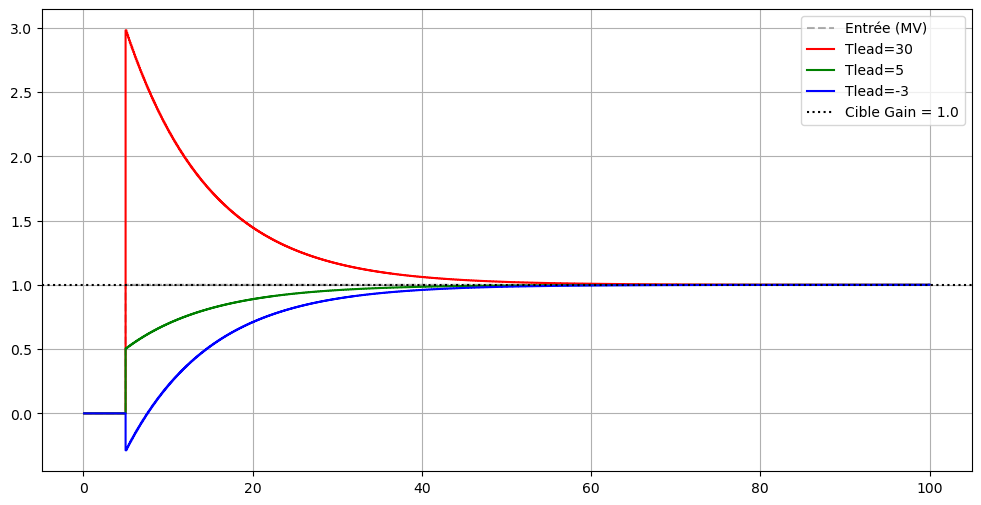

In [20]:
import numpy as np
import matplotlib.pyplot as plt


TSim = 100
Ts = 0.1 
N = int(TSim/Ts) + 1
t = []
MV = [] 
PV_lead = []; PV_lead2 = []; PV_lead3 = [] 

MVPath = {0: 0, 5: 1, TSim: 1}
Tlag_fixe = 10.0
Kp = 1.0


for i in range(1, N):
    t.append(i * Ts)
    SelectPath_RT(MVPath, t, MV)
    
    LL_RT(MV, Kp, 30.0, Tlag_fixe, Ts, PV_lead, method='EBD')
    LL_RT(MV, Kp, 5.0,  Tlag_fixe, Ts, PV_lead2, method='EBD')
    LL_RT(MV, Kp, -3.0, Tlag_fixe, Ts, PV_lead3, method='EBD')

plt.figure(figsize=(12, 6))
plt.step(t, MV, 'k--', label='Entrée (MV)', where='post', alpha=0.3)
plt.step(t, PV_lead, 'r-', label='Tlead=30 ', where='post')
plt.step(t, PV_lead2, 'g-', label='Tlead=5 ', where='post')
plt.step(t, PV_lead3, 'b-', label='Tlead=-3 ', where='post')
plt.axhline(y=Kp, color='k', linestyle=':', label='Cible Gain = 1.0')
plt.legend(); plt.grid(True); plt.show()

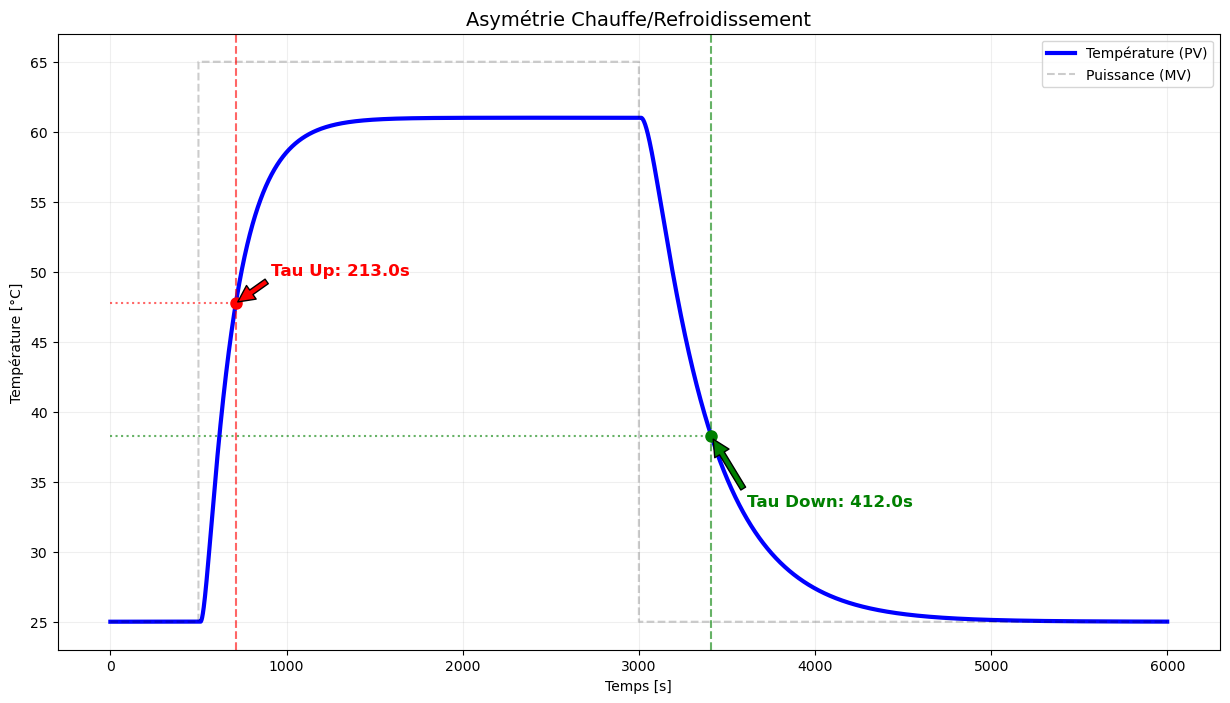

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. ENTRE TES PARAMÈTRES ICI ---
Kp_user = 0.36    # Ton gain statique
T1_user = 170.82    # Ta constante de temps dominante (Tp1)
T2_user = 26.55      # Ta deuxième constante de temps (Tp2)
theta_user = 13.31   # Ton délai (theta)
Ts = 1            # Temps d'échantillonnage
PV0 = 25          # Température ambiante de départ
# ------------------------------------

def FO_RT_logic(val_in, Kp, Tlag, Ts, PV_list):
    if len(PV_list) == 0: PV_list.append(0)
    else:
        den = Tlag + Ts
        PV_list.append((Tlag/den)*PV_list[-1] + (Kp*Ts/den)*val_in)

def SOPDT_sim(t, MV, Kp, T1, T2, theta, Ts, PV0, cooling_factor=2.0):
    PV1, PV2 = [], []
    delay_steps = int(theta/Ts)
    for i in range(len(t)):
        idx_delayed = max(0, i - delay_steps)
        val_delayed = MV[idx_delayed]
        # On ralentit les constantes de temps si on refroidit (MV = 0)
        factor = cooling_factor if MV[i] < 5 else 1.0
        FO_RT_logic(val_delayed, Kp, T1 * factor, Ts, PV1)
        FO_RT_logic(PV1[-1], 1.0, T2 * factor, Ts, PV2)
    return np.array(PV2) + PV0

def find_tau_points(t, pv, t_start, pv_initial, pv_final):
    idx_start = np.argmin(np.abs(t - t_start))
    t_seg, pv_seg = t[idx_start:], pv[idx_start:]
    delta_total = pv_final - pv_initial
    target = pv_initial + 0.632 * delta_total
    
    crossings = np.where(pv_seg >= target)[0] if delta_total > 0 else np.where(pv_seg <= target)[0]
    if len(crossings) > 0:
        t_tau_abs = t_seg[crossings[0]]
        return t_tau_abs - t_start, t_tau_abs, target
    return np.nan, np.nan, target

# Simulation sur 6000 secondes
t = np.arange(0, 6000, Ts)
MV = np.zeros(len(t))
MV[500:3000] = 100 # Chauffe à 100%
MV[3000:] = 0      # On coupe tout

PV = SOPDT_sim(t, MV, Kp_user, T1_user, T2_user, theta_user, Ts, PV0)
pv_max = PV0 + Kp_user * 100

# Identification des Tau
tau_up, t_up, val_up = find_tau_points(t, PV, 500, PV0, pv_max)
tau_down, t_down, val_down = find_tau_points(t, PV, 3000, pv_max, PV0)

# --- GRAPHIQUE ---
plt.figure(figsize=(15, 8))
plt.plot(t, PV, 'b-', lw=3, label='Température (PV)')
plt.step(t, MV*0.4 + 25, 'k--', alpha=0.2, label='Puissance (MV)', where='post') # Scaled MV for viz

# Tracé Tau Montée (Rouge)
plt.axvline(t_up, color='red', linestyle='--', alpha=0.6)
plt.hlines(val_up, 0, t_up, colors='red', linestyles=':', alpha=0.6)
plt.plot(t_up, val_up, 'ro', markersize=8)
plt.annotate(f'Tau Up: {tau_up:.1f}s', xy=(t_up, val_up), xytext=(t_up+200, val_up+2),
             arrowprops=dict(facecolor='red', shrink=0.05), color='red', fontsize=12, fontweight='bold')

# Tracé Tau Descente (Vert)
plt.axvline(t_down, color='green', linestyle='--', alpha=0.6)
plt.hlines(val_down, 0, t_down, colors='green', linestyles=':', alpha=0.6)
plt.plot(t_down, val_down, 'go', markersize=8)
plt.annotate(f'Tau Down: {tau_down:.1f}s', xy=(t_down, val_down), xytext=(t_down+200, val_down-5),
             arrowprops=dict(facecolor='green', shrink=0.05), color='green', fontsize=12, fontweight='bold')

plt.title(f'Asymétrie Chauffe/Refroidissement', fontsize=14)
plt.xlabel('Temps [s]')
plt.ylabel('Température [°C]')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()